# Two-tier difficulty router on a mixed-difficulty benchmark

The GSM8K run showed two problems: the classifier never said "hard", and the middle model was *worse* than the cheap one. So this version has two tiers, ordered by measured ability:

| Label | Model | $/1M in / out |
|---|---|---|
| classifier | `gpt-oss-120b` | 0.15 / 0.60 |
| easy | `gpt-oss-120b` | 0.15 / 0.60 |
| hard | `kimi-k3` | 3.00 / 15.00 |

The benchmark mixes three sources so difficulty genuinely varies and there is headroom above the cheap model:

| Bucket | Source |
|---|---|
| easy | GSM8K test |
| medium | MATH Level 3 (numeric answers only) |
| hard | AIME 2022-2024 (`AI-MO/aimo-validation-aime`) |

That first mix turned out too easy: two thirds of it scored 97-100% for every model, so the worst setup still got 91%. Setting `BENCH = "hard"` in the config cell switches to a harder set, with its own results file (`results_hard.jsonl`), so the first run stays reproducible with `BENCH = "mixed"`:

| Bucket | Hard set source |
|---|---|
| easy | MATH Level 5 (numeric answers only), 50 |
| medium | AIME 2022-2024, 50 |
| hard | AIME 2025 (30) + HMMT February 2025 integer-answer problems (~14) |

Policies: **routed**, **only-easy** (`gpt-oss-120b` for everything), **only-hard** (`kimi-k3` for everything). Each question is its own agent run, so earlier questions never inflate later costs. The last section runs a single shuffled conversation so you can watch the router switch turn by turn.

**Cost per successful task** = total spend across all attempts (failures and classifier calls included) / number of successes.

In [1]:
# %pip install -q langchain langchain-fireworks datasets matplotlib tqdm
import json, math, random, threading
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
from datasets import load_dataset
from langchain.agents import create_agent
from langchain_core.messages import AIMessage
from tqdm.auto import tqdm

from difficulty_router import (CLASSIFIER_MODEL, COMPLETION_BUDGET_FLOOR, PRICES, SYSTEM_PROMPT, TWO_TIER_PROMPT,
                               TWO_TIERS, DifficultyRouterMiddleware, calculator, chat, extract_answer,
                               message_cost, run_cost)

N_PER_BUCKET = 50        # questions per bucket -> 150 total
N_SAMPLES = 4            # draws per question -> pass@k / pass^k curves
K_VALUES = [1, 2, 3, 4]
MAX_WORKERS = 8
SEED = 0
MAX_TOKENS = 32_000      # AIME reasoning runs long; a low cap returns empty answers
assert MAX_TOKENS >= COMPLETION_BUDGET_FLOOR
# "mixed": GSM8K / MATH L3 / AIME 2022-24 (the first run).
# "hard":  MATH L5 / AIME 2022-24 / AIME 2025 + HMMT 2025, with its own results file.
BENCH = "hard"
if BENCH == "mixed":
    OUT, BENCH_NAME, TIMEOUT_S = Path("results_mixed.jsonl"), "Mixed GSM8K / MATH L3 / AIME", 600
else:
    OUT, BENCH_NAME, TIMEOUT_S = Path("results_hard.jsonl"), "Hard MATH L5 / AIME 22-24 / AIME+HMMT 2025", 1200
rng = random.Random(SEED)


def last_boxed(s):
    i = s.rfind("\\boxed")
    if i < 0:
        return None
    j = s.find("{", i)
    depth, k = 0, j
    while k < len(s):
        depth += {"{": 1, "}": -1}.get(s[k], 0)
        if depth == 0:
            return s[j + 1:k]
        k += 1
    return None


def to_float(s):
    try:
        return float(str(s).replace(",", "").replace("$", "").replace("\\!", "").strip())
    except (TypeError, ValueError):
        return None


questions = {}  # qid -> dict(bucket, question, gold)

from mixed_bench import load_hard_mix, load_mixed

if BENCH == "mixed":
    questions = load_mixed(n_per_bucket=N_PER_BUCKET, seed=SEED)   # identical to the first run's 150 questions
else:
    questions = load_hard_mix(n_math=N_PER_BUCKET, n_aime=N_PER_BUCKET, seed=SEED)

assert all(v["gold"] is not None for v in questions.values())
qids = list(questions)
N_QUESTIONS = len(qids)
print(BENCH_NAME, "|", Counter(v["bucket"] for v in questions.values()), f"x {N_SAMPLES} draws")

/Users/sinan/cookbook/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hard MATH L5 / AIME 22-24 / AIME+HMMT 2025 | Counter({'easy': 50, 'medium': 50, 'hard': 44}) x 4 draws


In [2]:
# reasoning_effort=low: at default effort the classifier solves the problem and labels it by whether it succeeded
CLASSIFIER_KWARGS = {"reasoning_effort": "low"}
router = DifficultyRouterMiddleware(tiers=TWO_TIERS, default_tier="hard", prompt=TWO_TIER_PROMPT,
                                    max_tokens=MAX_TOKENS, timeout=TIMEOUT_S, classifier_kwargs=CLASSIFIER_KWARGS)
POLICIES = {
    "routed": create_agent(model=router.models["easy"], tools=[calculator], system_prompt=SYSTEM_PROMPT,
                           middleware=[router]),
    **{f"only-{tier}": create_agent(model=chat(m, max_tokens=MAX_TOKENS, timeout=TIMEOUT_S), tools=[calculator],
                                    system_prompt=SYSTEM_PROMPT)
       for tier, m in TWO_TIERS.items()},
}

# Rough per-run output tokens by bucket (reasoning included); input ~3k per run.
OUT_TOKENS = {"easy": 1_500, "medium": 4_000, "hard": 15_000}
def est_run(model, bucket):
    return (3_000 * PRICES[model][0] + OUT_TOKENS[bucket] * PRICES[model][2]) / 1e6
est = {}
for p, m in [("only-easy", TWO_TIERS["easy"]), ("only-hard", TWO_TIERS["hard"])]:
    est[p] = sum(est_run(m, b) for b in OUT_TOKENS) * N_PER_BUCKET * N_SAMPLES
# routed: assume the classifier sends medium+hard to kimi-k3, easy to gpt-oss-120b
clf = (600 * PRICES[CLASSIFIER_MODEL][0] + 1_000 * PRICES[CLASSIFIER_MODEL][2]) / 1e6
est["routed"] = (est_run(TWO_TIERS["easy"], "easy") + est_run(TWO_TIERS["hard"], "medium")
                 + est_run(TWO_TIERS["hard"], "hard") + 3 * clf) * N_PER_BUCKET * N_SAMPLES
for p, c in est.items():
    print(f"{p:10s} ~${c:.2f}")
print(f"estimated total ~${sum(est.values()):.2f} (kimi-k3 on AIME dominates)")

only-easy  ~$2.73
only-hard  ~$66.90
routed     ~$61.28
estimated total ~$130.91 (kimi-k3 on AIME dominates)


/var/folders/0h/c6c4v8153bz0v35w1mcvqvpw0000gn/T/ipykernel_76049/4069131279.py:3: UserWarning: Parameters {'reasoning_effort'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  router = DifficultyRouterMiddleware(tiers=TWO_TIERS, default_tier="hard", prompt=TWO_TIER_PROMPT,


In [3]:
# Scion as a fourth policy. Label every question once (cached in scion_labels.json), then route live from the cache,
# so the Scion deployment only has to be up while new questions are being labelled, not during the agent runs.
import importlib, os, time
from fireworks import Fireworks
import scion_router
importlib.reload(scion_router)   # pick up edits to scion_router.py (e.g. a new DEPLOYMENT_ID) without a kernel restart
from scion_router import BASE_MODEL, DEPLOYMENT_ID, SCION_LORA, SCION_TEMPERATURE, ScionClassifier
print("Scion deployment id:", DEPLOYMENT_ID)

SCION_THRESHOLD = 0.5
SCION_CACHE = Path("scion_labels.json")     # qid -> calibrated P(hard)
fw = Fireworks()
ACCT = os.environ["FIREWORKS_ACCOUNT_ID"].replace("accounts/", "")
DEPLOYMENT = f"accounts/{ACCT}/deployments/{DEPLOYMENT_ID}"
scion = ScionClassifier()
p_hard = json.loads(SCION_CACHE.read_text()) if SCION_CACHE.exists() else {}
todo = [q for q in qids if q not in p_hard]
print(f"Scion = {SCION_LORA.split('/')[-1]}, T = {SCION_TEMPERATURE:.2f}; {len(qids) - len(todo)} cached, {len(todo)} to classify")

if todo:
    spec = dict(base_model=BASE_MODEL, deployment_id=DEPLOYMENT_ID, accelerator_type="NVIDIA_H100_80GB",
                enable_addons=True, min_replica_count=1, max_replica_count=1, extra_query={"acceptShapelessRisk": "true"})
    from fireworks import NotFoundError
    try:
        dep = fw.deployments.get(DEPLOYMENT_ID)
    except NotFoundError:
        dep = None
    if dep is None:
        fw.deployments.create(**spec, validate_only=True)
        fw.deployments.create(**spec)
    else:
        print(f"[{DEPLOYMENT_ID}] exists, state={dep.state}")
        if str(dep.state) in ("DELETED", "DELETING", "FAILED"):
            raise RuntimeError(f"{DEPLOYMENT_ID} is {dep.state}: that id stays reserved and can't be revived. "
                               "Set DEPLOYMENT_ID in scion_router.py to a fresh id and restart the kernel.")
        fw.deployments.update(DEPLOYMENT_ID, base_model=BASE_MODEL, min_replica_count=1, max_replica_count=1)
        fw.deployments.scale(DEPLOYMENT_ID, replica_count=1)
    for i in range(240):
        st = fw.deployments.get(DEPLOYMENT_ID).state
        print(f"[{DEPLOYMENT_ID}] {i + 1:03d} state={st}", flush=True)
        if st == "READY":
            break
        time.sleep(15)
    try:
        fw.lora.load(model=SCION_LORA, deployment=DEPLOYMENT)
    except Exception as e:  # noqa: BLE001
        print("lora.load:", str(e)[:100], "(fine if already loaded)")
    for i in range(60):
        try:
            scion.p_hard("What is 2 + 2?")
            print("Scion serving")
            break
        except Exception as e:  # noqa: BLE001
            print(f"[scion] {i + 1:02d} not ready: {str(e)[:80]}", flush=True)
            time.sleep(20)
    with ThreadPoolExecutor(8) as pool:
        futs = {pool.submit(scion.p_hard, questions[q]["question"]): q for q in todo}
        for fut in tqdm(as_completed(futs), total=len(futs), desc="Scion classify"):
            p_hard[futs[fut]] = fut.result()
            SCION_CACHE.write_text(json.dumps(p_hard))
    # Labelling done: stop paying for the deployment before the long agent run.
    fw.deployments.update(DEPLOYMENT_ID, base_model=BASE_MODEL, min_replica_count=0, max_replica_count=1)
    fw.deployments.scale(DEPLOYMENT_ID, replica_count=0)
    print(f"[{DEPLOYMENT_ID}] scaled to 0")

for b in ["easy", "medium", "hard"]:
    ps = [p_hard[q] for q in qids if questions[q]["bucket"] == b]
    print(f"{b:6s} mean P(hard) {sum(ps) / len(ps):.2f} | share >= {SCION_THRESHOLD}: "
          f"{sum(p >= SCION_THRESHOLD for p in ps) / len(ps):.0%}")

P_BY_TEXT = {questions[q]["question"]: p_hard[q] for q in qids}


def scion_cached(task):
    """classify_fn: cached calibrated P(hard) -> label. Scion runs on a GPU-hour deployment, so per-call cost is 0."""
    p = P_BY_TEXT.get(task)
    return (None if p is None else ("hard" if p >= SCION_THRESHOLD else "easy")), 0.0


scion_router = DifficultyRouterMiddleware(tiers=TWO_TIERS, default_tier="hard", prompt=TWO_TIER_PROMPT,
                                          max_tokens=MAX_TOKENS, timeout=TIMEOUT_S, classify_fn=scion_cached)
POLICIES["scion-routed"] = create_agent(model=scion_router.models["easy"], tools=[calculator],
                                        system_prompt=SYSTEM_PROMPT, middleware=[scion_router])
print("policies:", list(POLICIES))

Scion deployment id: jev-di-9b-0928
Scion = jev-9b-v4-repeat-15a8ac, T = 1.73; 144 cached, 0 to classify
easy   mean P(hard) 0.36 | share >= 0.5: 26%
medium mean P(hard) 0.67 | share >= 0.5: 82%
hard   mean P(hard) 0.68 | share >= 0.5: 91%
policies: ['routed', 'only-easy', 'only-hard', 'scion-routed']


## Run all policies

Jobs are interleaved across policies and buckets, so partial results are always a fair comparison.

In [4]:
done = set()
if OUT.exists():
    for line in OUT.open():
        r = json.loads(line)
        done.add((r["policy"], r["qid"], r["draw"]))
jobs = [(p, q, d) for d in range(N_SAMPLES) for q in qids for p in POLICIES if (p, q, d) not in done]
random.Random(SEED + 1).shuffle(jobs)
print(f"{len(done)} already done, {len(jobs)} to run")

lock = threading.Lock()

def correct(pred, gold):
    return pred is not None and abs(pred - gold) <= 1e-4 * max(1.0, abs(gold))

def run_one(policy, qid, draw):
    q = questions[qid]
    try:
        out = POLICIES[policy].invoke({"messages": [{"role": "user", "content": q["question"]}]})
        text = out["messages"][-1].text
        if not text.strip():
            raise RuntimeError("empty final answer")
        pred = extract_answer(text)
        rec = dict(policy=policy, qid=qid, bucket=q["bucket"], draw=draw, pred=pred, gold=q["gold"],
                   correct=correct(pred, q["gold"]), cost=run_cost(out),
                   difficulty=out.get("difficulty"), model=out.get("routed_model"),
                   n_model_calls=sum(m.type == "ai" for m in out["messages"]), error=None)
    except Exception as e:  # a failed attempt still counts as an attempt; cost unknown -> 0, flagged
        rec = dict(policy=policy, qid=qid, bucket=q["bucket"], draw=draw, pred=None, gold=q["gold"],
                   correct=False, cost=0.0, difficulty=None, model=None, n_model_calls=0, error=repr(e)[:300])
    with lock, OUT.open("a") as f:
        f.write(json.dumps(rec) + "\n")
    return rec

stats = defaultdict(lambda: [0, 0, 0.0, 0])  # correct, total, cost, errors
with ThreadPoolExecutor(MAX_WORKERS) as ex:
    futs = [ex.submit(run_one, *j) for j in jobs]
    bar = tqdm(as_completed(futs), total=len(futs))
    for i, f in enumerate(bar):
        r = f.result()
        s = stats[r["policy"]]
        s[0] += r["correct"]; s[1] += 1; s[2] += r["cost"]; s[3] += r["error"] is not None
        bar.set_postfix({p: f"{v[0]}/{v[1]}" for p, v in stats.items()})
        if i % 50 == 0:
            print({p: dict(acc=round(v[0] / v[1], 3), usd=round(v[2], 2), err=v[3]) for p, v in stats.items()})
print("unparseable classifier labels (defaulted to hard):", router.unparseable)

2304 already done, 0 to run


0it [00:00, ?it/s]

unparseable classifier labels (defaulted to hard): 0


## Results: accuracy, cost per successful task, where the router sent each bucket

In [5]:
recs = [json.loads(l) for l in OUT.open()]
recs = [r for r in recs if r["qid"] in questions and r["draw"] < N_SAMPLES]
by_policy = defaultdict(list)
for r in recs:
    by_policy[r["policy"]].append(r)

def summarize(rs):
    n, c = len(rs), sum(r["correct"] for r in rs)
    spend = sum(r["cost"] for r in rs)
    acc = c / n
    half = 1.96 * math.sqrt(acc * (1 - acc) / n)
    return dict(attempts=n, acc=acc, acc_lo=acc - half, acc_hi=acc + half, spend=spend, per_attempt=spend / n,
                per_success=spend / c if c else float("inf"), retry_tax=n / c if c else float("inf"),
                errors=sum(r["error"] is not None for r in rs))

rows = sorted([dict(policy=p, **summarize(rs)) for p, rs in by_policy.items()], key=lambda r: r["per_success"])
print(f"{'policy':10s} {'acc':>6s} {'95% range':>15s} {'total $':>8s} {'$/attempt':>10s} {'$/success':>10s} {'retry tax':>9s} {'errors':>6s}")
for r in rows:
    print(f"{r['policy']:10s} {r['acc']:6.3f} [{r['acc_lo']:.3f},{r['acc_hi']:.3f}] {r['spend']:8.2f} "
          f"{r['per_attempt']:10.5f} {r['per_success']:10.5f} {r['retry_tax']:8.2f}x {r['errors']:6d}")

print("\naccuracy and $/success by bucket")
for b in ["easy", "medium", "hard"]:
    cells = []
    for p in POLICIES:
        s = summarize([r for r in by_policy[p] if r["bucket"] == b]) if by_policy[p] else None
        cells.append(f"{p}: {s['acc']:.3f} @ ${s['per_success']:.4f}" if s else f"{p}: -")
    print(f"  {b:6s} | " + " | ".join(cells))

print("\nrouting: rows = true bucket, columns = classifier label (share of routed runs)")
routed = by_policy["routed"]
for b in ["easy", "medium", "hard"]:
    rs = [r for r in routed if r["bucket"] == b]
    lab = Counter(r["difficulty"] for r in rs)
    print(f"  {b:6s} n={len(rs):4d}  " + "  ".join(f"{l}={lab[l] / len(rs):.0%}" for l in TWO_TIERS) if rs else f"  {b}: -")

# Oracle: for each question, the cheaper model if it gets it right on draw 0, else kimi-k3. Upper bound for any router.
per = {p: {(r["qid"], r["draw"]): r for r in by_policy[p]} for p in ["only-easy", "only-hard"]}
keys = set(per["only-easy"]) & set(per["only-hard"])
if keys:
    pick = [per["only-easy"][k] if per["only-easy"][k]["correct"] else per["only-hard"][k] for k in keys]
    o = summarize(pick)
    print(f"\noracle router (perfect hindsight): acc={o['acc']:.3f}  $/success={o['per_success']:.5f}")

policy        acc       95% range  total $  $/attempt  $/success retry tax errors
only-easy   0.838 [0.808,0.868]     2.17    0.00374    0.00446     1.19x      0
scion-routed  0.917 [0.895,0.940]    52.26    0.09011    0.09824     1.09x      5
routed      0.914 [0.891,0.937]    54.62    0.09402    0.10287     1.09x      6
only-hard   0.913 [0.891,0.936]    58.35    0.10094    0.11050     1.09x      5

accuracy and $/success by bucket
  easy   | routed: 0.955 @ $0.0292 | only-easy: 0.985 @ $0.0013 | only-hard: 0.941 @ $0.0391 | scion-routed: 0.960 @ $0.0206
  medium | routed: 0.871 @ $0.1464 | only-easy: 0.781 @ $0.0073 | only-hard: 0.890 @ $0.1516 | scion-routed: 0.910 @ $0.1368
  hard   | routed: 0.916 @ $0.1427 | only-easy: 0.734 @ $0.0059 | only-hard: 0.909 @ $0.1496 | scion-routed: 0.876 @ $0.1490

routing: rows = true bucket, columns = classifier label (share of routed runs)
  easy   n= 201  easy=55%  hard=45%
  medium n= 202  easy=10%  hard=87%
  hard   n= 178  easy=4%  hard=95%


## Pass curves

- **pass@k**: if it tries k times, does *any* try succeed?
- **pass^k**: if it tries k times, does *every* try succeed? (consistency)
- Bottom row: the same curves per bucket, which is where routing should show up.

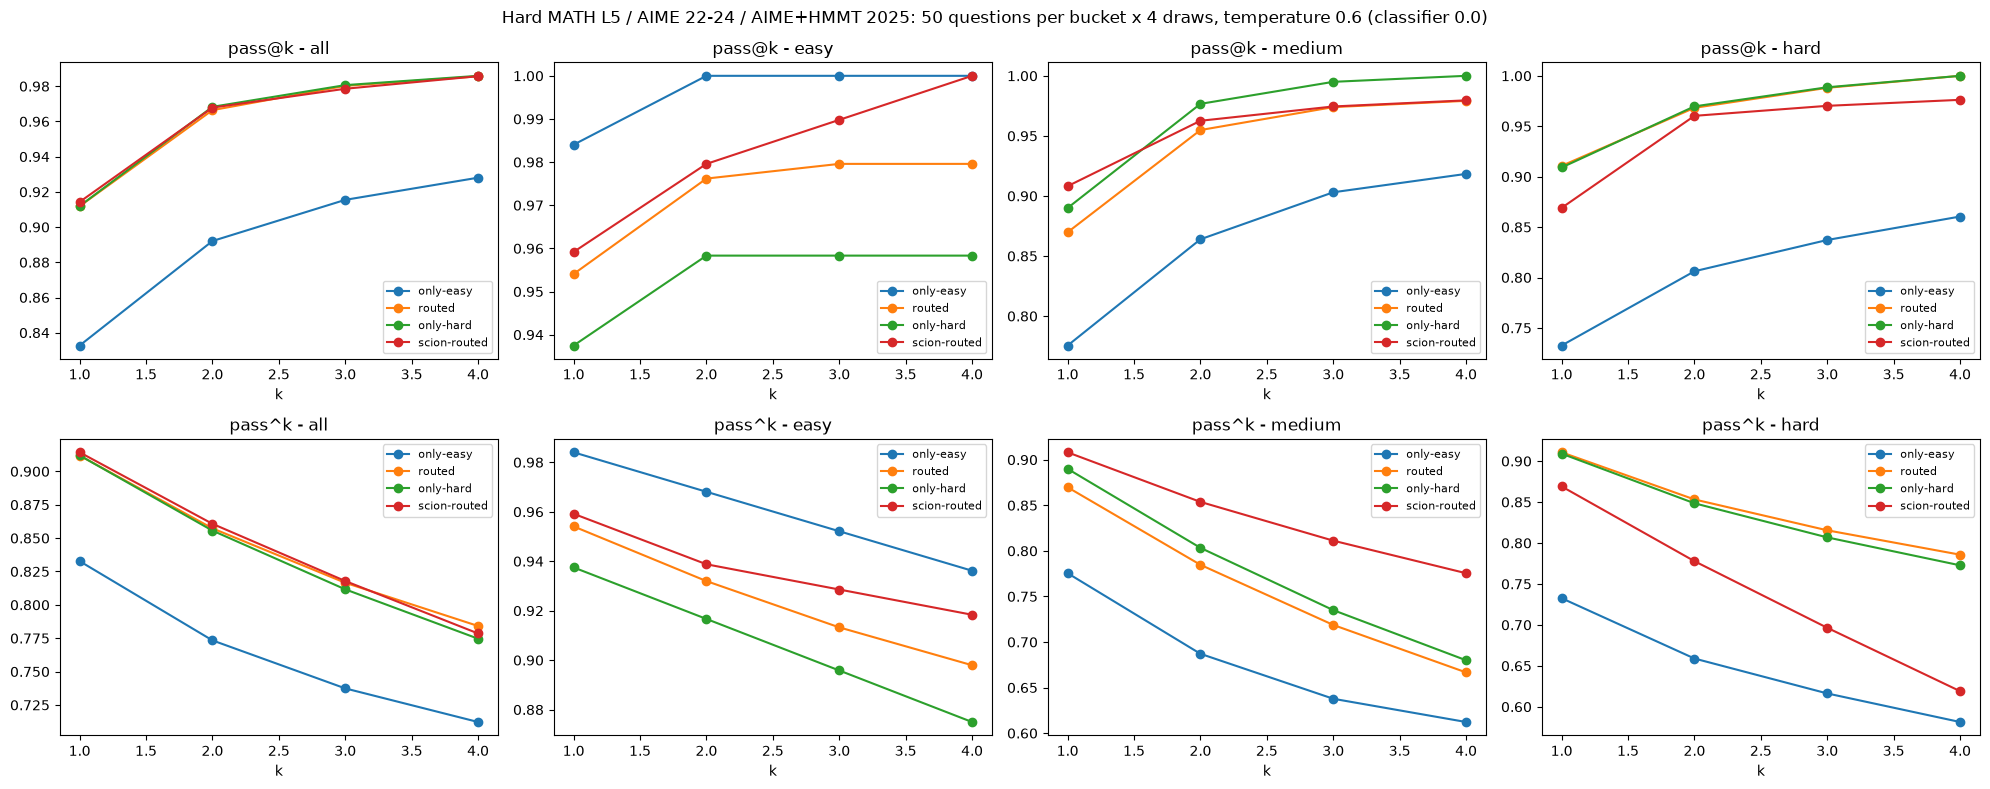

In [7]:
def pass_at_k(n, c, k):
    return 1.0 if n - c < k else 1 - math.comb(n - c, k) / math.comb(n, k)

def pass_hat_k(n, c, k):
    return math.comb(c, k) / math.comb(n, k)

def curves(rs):
    per_q = defaultdict(list)
    for r in rs:
        per_q[r["qid"]].append(r)
    cs = [sum(r["correct"] for r in v) for v in per_q.values() if len(v) == N_SAMPLES]
    if not cs:
        return None, None
    return ([sum(pass_at_k(N_SAMPLES, c, k) for c in cs) / len(cs) for k in K_VALUES],
            [sum(pass_hat_k(N_SAMPLES, c, k) for c in cs) / len(cs) for k in K_VALUES])

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
groups = [("all", None), ("easy", "easy"), ("medium", "medium"), ("hard", "hard")]
for col, (name, b) in enumerate(groups):
    for p, rs in by_policy.items():
        at, hat = curves([r for r in rs if b is None or r["bucket"] == b])
        if at:
            axes[0, col].plot(K_VALUES, at, "o-", label=p)
            axes[1, col].plot(K_VALUES, hat, "o-", label=p)
    axes[0, col].set_title(f"pass@k - {name}"); axes[1, col].set_title(f"pass^k - {name}")
    for row in range(2):
        axes[row, col].set_xlabel("k"); axes[row, col].legend(fontsize=8)
fig.suptitle(f"{BENCH_NAME}: {N_PER_BUCKET} questions per bucket x {N_SAMPLES} draws, temperature 0.6 (classifier 0.0)")
plt.tight_layout(); plt.savefig("fig_mixed_pass_curves.png", dpi=150); plt.show()

## Live demo: one shuffled conversation, watch the router switch

One agent with a checkpointer; each turn is a new question from a random bucket. The router re-classifies the **latest** user message every turn, so the model switches mid-conversation. This is a demo, not the benchmark: context accumulates across turns, so per-turn cost grows.

/var/folders/0h/c6c4v8153bz0v35w1mcvqvpw0000gn/T/ipykernel_76049/2113640908.py:4: UserWarning: Parameters {'reasoning_effort'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  demo_router = DifficultyRouterMiddleware(tiers=TWO_TIERS, default_tier="hard", prompt=TWO_TIER_PROMPT,
conversation:   8%|▊         | 1/12 [01:38<18:02, 98.39s/it]

turn  0 | true=easy   | router -> hard (kimi-k3      ) | OK  pred=4.0 gold=4.0 | $0.0707


conversation:  17%|█▋        | 2/12 [01:59<08:49, 52.95s/it]

turn  1 | true=medium | router -> easy (gpt-oss-120b ) | OK  pred=550.0 gold=550.0 | $0.0026


conversation:  25%|██▌       | 3/12 [02:13<05:17, 35.26s/it]

...

turn  9 | true=medium | router -> hard (kimi-k3      ) | MISS pred=377.0 gold=371.0 | $0.2449


conversation:  92%|█████████▏| 11/12 [40:40<04:42, 282.99s/it]

turn 10 | true=easy   | router -> hard (kimi-k3      ) | OK  pred=1.0 gold=1.0 | $0.0190


conversation: 100%|██████████| 12/12 [40:54<00:00, 204.55s/it]

turn 11 | true=hard   | router -> easy (gpt-oss-120b ) | OK  pred=16.0 gold=16.0 | $0.0065


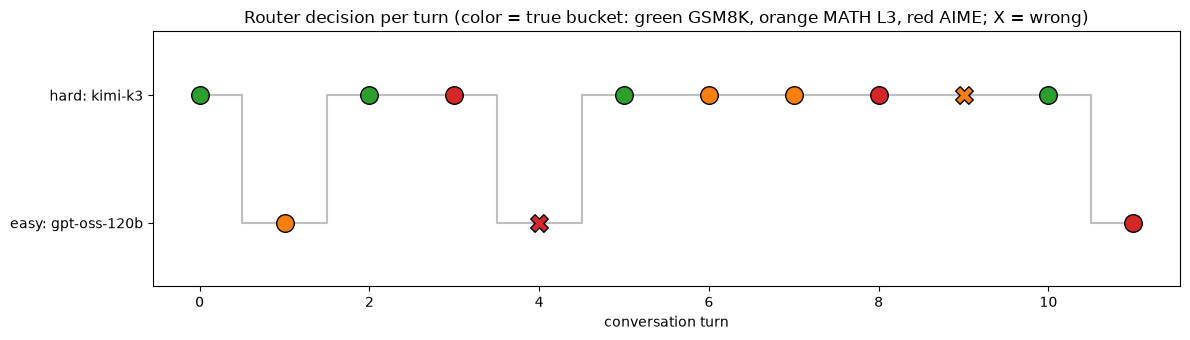

conversation total $1.379, 10/12 correct


In [8]:
from langgraph.checkpoint.memory import InMemorySaver

DEMO_TURNS_PER_BUCKET = 4
demo_router = DifficultyRouterMiddleware(tiers=TWO_TIERS, default_tier="hard", prompt=TWO_TIER_PROMPT,
                                         max_tokens=MAX_TOKENS, timeout=TIMEOUT_S, classifier_kwargs=CLASSIFIER_KWARGS)
demo_agent = create_agent(model=demo_router.models["easy"], tools=[calculator], system_prompt=SYSTEM_PROMPT,
                          middleware=[demo_router], checkpointer=InMemorySaver())
demo_rng = random.Random(SEED + 2)
turns = [q for b in ["easy", "medium", "hard"]
         for q in demo_rng.sample([k for k in qids if questions[k]["bucket"] == b], DEMO_TURNS_PER_BUCKET)]
demo_rng.shuffle(turns)

config = {"configurable": {"thread_id": "mixed-demo"}}
timeline, seen = [], 0
for t, qid in enumerate(tqdm(turns, desc="conversation")):
    q = questions[qid]
    out = demo_agent.invoke({"messages": [{"role": "user", "content": q["question"]}]}, config)
    new = out["messages"][seen:]
    seen = len(out["messages"])
    cost = out["router_cost_usd"] + sum(message_cost(m) for m in new if isinstance(m, AIMessage))
    pred = extract_answer(out["messages"][-1].text)
    ok = correct(pred, q["gold"])
    timeline.append(dict(turn=t, bucket=q["bucket"], label=out["difficulty"], model=out["routed_model"],
                         correct=ok, cost=cost))
    print(f"turn {t:2d} | true={q['bucket']:6s} | router -> {out['difficulty']:4s} "
          f"({out['routed_model'].split('/')[-1]:13s}) | {'OK ' if ok else 'MISS'} pred={pred} gold={q['gold']} | ${cost:.4f}")

fig, ax = plt.subplots(figsize=(12, 3.5))
ylev = {"easy": 0, "hard": 1}
colors = {"easy": "tab:green", "medium": "tab:orange", "hard": "tab:red"}
ax.step([r["turn"] for r in timeline], [ylev[r["label"]] for r in timeline], where="mid", color="gray", alpha=0.5)
for r in timeline:
    ax.scatter(r["turn"], ylev[r["label"]], s=160, color=colors[r["bucket"]], marker="o" if r["correct"] else "X",
               edgecolor="black", zorder=3)
ax.set_yticks([0, 1], [f"easy: {TWO_TIERS['easy'].split('/')[-1]}", f"hard: {TWO_TIERS['hard'].split('/')[-1]}"])
ax.set_ylim(-0.5, 1.5); ax.set_xlabel("conversation turn")
ax.set_title("Router decision per turn (color = true bucket: green GSM8K, orange MATH L3, red AIME; X = wrong)")
plt.tight_layout(); plt.savefig("fig_mixed_conversation.png", dpi=150); plt.show()
print(f"conversation total ${sum(r['cost'] for r in timeline):.3f}, "
      f"{sum(r['correct'] for r in timeline)}/{len(timeline)} correct")

## Scion as the router

[Scion](../scion/) is a fine-tuned decision classifier: v4 (Qwen3.5 9B LoRA) with prompt repetition and
its calibration temperature. Here it replaces the gpt-oss-120b classifier through the middleware's
`classify_fn` hook. It answers one decision per task, *"would a capable but cheaper model plausibly get
this wrong?"*, and returns a **calibrated probability of hard**, so the routing threshold is a dial:
lower it and more tasks go to kimi-k3 (more accurate, more expensive).

Scion was never trained on difficulty, so this is a zero-shot transfer test. It runs on a dedicated
deployment billed by GPU time, so its per-call token cost is counted as 0; the deployment time for 150
classifications is a few minutes.

**Evaluation without re-solving.** The runs above already hold gpt-oss-120b's and kimi-k3's answers to
every question (4 draws each). A Scion-routed attempt is the cheap model's saved attempt when Scion says
easy and kimi-k3's when it says hard, so accuracy and $ per success for any threshold come out exactly,
with no new solver calls. The gpt-oss router used its own draws, which are an equivalent sample.

In [9]:
import os, time
from fireworks import Fireworks
from scion_router import BASE_MODEL, DEPLOYMENT_ID, SCION_LORA, SCION_TEMPERATURE, ScionClassifier

SCION_CACHE = Path("scion_labels.json")     # qid -> calibrated P(hard); rerunning skips cached questions
fw = Fireworks()
ACCT = os.environ["FIREWORKS_ACCOUNT_ID"].replace("accounts/", "")
DEPLOYMENT = f"accounts/{ACCT}/deployments/{DEPLOYMENT_ID}"
scion = ScionClassifier()
p_hard = json.loads(SCION_CACHE.read_text()) if SCION_CACHE.exists() else {}
todo = [q for q in qids if q not in p_hard]
print(f"Scion = {SCION_LORA.split('/')[-1]}, T = {SCION_TEMPERATURE:.2f}; {len(p_hard)} cached, {len(todo)} to classify")

if todo:  # normally empty: the Scion cell before "Run all policies" already labelled every question
    spec = dict(base_model=BASE_MODEL, deployment_id=DEPLOYMENT_ID, accelerator_type="NVIDIA_H100_80GB",
                enable_addons=True, min_replica_count=1, max_replica_count=1, extra_query={"acceptShapelessRisk": "true"})
    try:
        fw.deployments.get(DEPLOYMENT_ID)
        fw.deployments.update(DEPLOYMENT_ID, base_model=BASE_MODEL, min_replica_count=1, max_replica_count=1)
        fw.deployments.scale(DEPLOYMENT_ID, replica_count=1)
    except Exception:  # noqa: BLE001  (deleted since the Decision Index runs)
        fw.deployments.create(**spec, validate_only=True)
        fw.deployments.create(**spec)
    for i in range(240):
        st = fw.deployments.get(DEPLOYMENT_ID).state
        print(f"[{DEPLOYMENT_ID}] {i + 1:03d} state={st}", flush=True)
        if st == "READY":
            break
        time.sleep(15)
    try:
        fw.lora.load(model=SCION_LORA, deployment=DEPLOYMENT)
    except Exception as e:  # noqa: BLE001
        print("lora.load:", str(e)[:100], "(fine if already loaded)")
    for i in range(60):
        try:
            scion.p_hard("What is 2 + 2?")
            print("Scion serving")
            break
        except Exception as e:  # noqa: BLE001
            print(f"[scion] {i + 1:02d} not ready: {str(e)[:80]}", flush=True)
            time.sleep(20)
    with ThreadPoolExecutor(8) as pool:
        futs = {pool.submit(scion.p_hard, questions[q]["question"]): q for q in todo}
        for fut in tqdm(as_completed(futs), total=len(futs), desc="Scion classify"):
            p_hard[futs[fut]] = fut.result()
            SCION_CACHE.write_text(json.dumps(p_hard))

for b in ["easy", "medium", "hard"]:
    ps = [p_hard[q] for q in qids if questions[q]["bucket"] == b]
    print(f"{b:6s} mean P(hard) {sum(ps) / len(ps):.2f} | share >= 0.5: {sum(p >= 0.5 for p in ps) / len(ps):.0%}")

Scion = jev-9b-v4-repeat-15a8ac, T = 1.73; 265 cached, 0 to classify
easy   mean P(hard) 0.36 | share >= 0.5: 26%
medium mean P(hard) 0.67 | share >= 0.5: 82%
hard   mean P(hard) 0.68 | share >= 0.5: 91%


In [10]:
easy_by = {(r["qid"], r["draw"]): r for r in by_policy["only-easy"]}
hard_by = {(r["qid"], r["draw"]): r for r in by_policy["only-hard"]}
KEYS = [k for k in easy_by if k in hard_by and k[0] in p_hard]


def scion_routed(threshold):
    out = []
    for k in KEYS:
        hard = p_hard[k[0]] >= threshold
        out.append({**(hard_by[k] if hard else easy_by[k]), "policy": f"routed-scion@{threshold:g}",
                    "difficulty": "hard" if hard else "easy"})   # Scion call itself: 0 token cost (dedicated)
    return out


THRESHOLDS = [round(t, 2) for t in np.arange(0.0, 1.0001, 0.05)] if "np" in globals() else [i / 20 for i in range(21)]
SWEEP = [dict(threshold=t, **summarize(scion_routed(t))) for t in THRESHOLDS]

base = {r["policy"]: r for r in rows if not r["policy"].startswith("routed-scion")}
SCION_ROW = dict(policy="routed-scion@0.5", **summarize(scion_routed(0.5)))
print(f"{'policy':18s} {'acc':>6s} {'$/success':>10s} {'share to kimi-k3':>16s}")
for name, r in [*base.items(), ("routed-scion@0.5", SCION_ROW)]:
    rs = by_policy.get(name) or scion_routed(0.5)
    to_hard = (sum(x.get("difficulty") == "hard" for x in rs) / len(rs)) if "routed" in name else (1.0 if name == "only-hard" else 0.0)
    print(f"{name:18s} {r['acc']:6.3f} {r['per_success']:10.5f} {to_hard:15.0%}")

print("\nwhere each router sends each bucket (share routed to kimi-k3)")
for b in ["easy", "medium", "hard"]:
    gpt = [r for r in by_policy["routed"] if r["bucket"] == b]
    sci = [r for r in scion_routed(0.5) if r["bucket"] == b]
    print(f"  {b:6s} gpt-oss classifier {sum(r['difficulty'] == 'hard' for r in gpt) / len(gpt):4.0%} | "
          f"Scion @0.5 {sum(r['difficulty'] == 'hard' for r in sci) / len(sci):4.0%}")

hard_acc = base["only-hard"]["acc"]
match = [s for s in SWEEP if s["acc"] >= hard_acc - 0.01]
if match:
    m = min(match, key=lambda s: s["per_success"])
    print(f"\ncheapest Scion threshold within 1 point of only-hard accuracy ({hard_acc:.3f}): t={m['threshold']}, "
          f"acc {m['acc']:.3f} at ${m['per_success']:.4f}/success vs only-hard ${base['only-hard']['per_success']:.4f}")

policy                acc  $/success share to kimi-k3
only-easy           0.838    0.00446              0%
scion-routed        0.917    0.09824             64%
routed              0.914    0.10287             75%
only-hard           0.913    0.11050            100%
routed-scion@0.5    0.929    0.09808             65%

where each router sends each bucket (share routed to kimi-k3)
  easy   gpt-oss classifier  45% | Scion @0.5  26%
  medium gpt-oss classifier  87% | Scion @0.5  82%
  hard   gpt-oss classifier  95% | Scion @0.5  91%

cheapest Scion threshold within 1 point of only-hard accuracy (0.913): t=0.75, acc 0.908 at $0.0632/success vs only-hard $0.1105


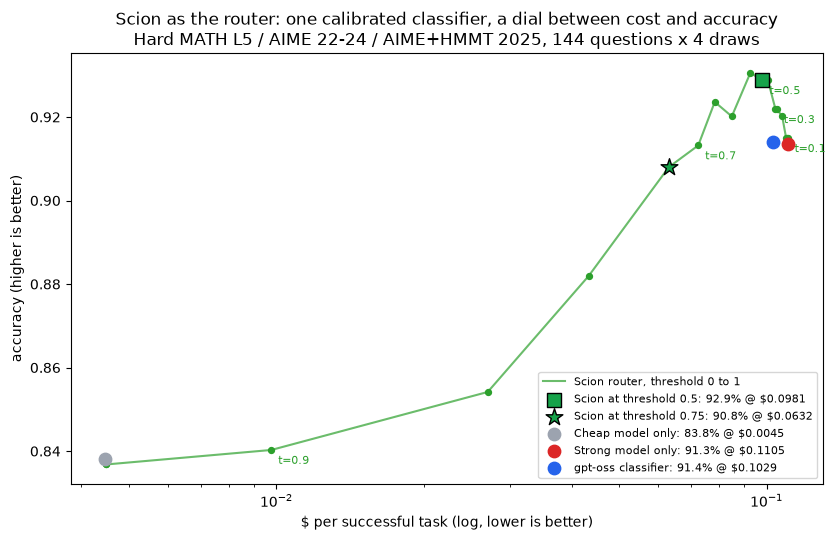

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot([s["per_success"] for s in SWEEP], [s["acc"] for s in SWEEP], "-", color="tab:green", alpha=0.7,
        label="Scion router, threshold 0 to 1")
for s in SWEEP:
    if s["threshold"] in (0.1, 0.3, 0.5, 0.7, 0.9):
        ax.annotate(f"t={s['threshold']:g}", (s["per_success"], s["acc"]), textcoords="offset points",
                    xytext=(5, -10), fontsize=8, color="tab:green")
ax.scatter([s["per_success"] for s in SWEEP], [s["acc"] for s in SWEEP], s=18, color="tab:green")
for t, mk in ((0.5, "s"), (0.75, "*")):
    s = next(x for x in SWEEP if abs(x["threshold"] - t) < 1e-9)
    ax.scatter(s["per_success"], s["acc"], s=160 if mk == "*" else 90, marker=mk, color="#16a34a", edgecolor="black",
               zorder=4, label=f"Scion at threshold {t:g}: {s['acc']:.1%} @ ${s['per_success']:.4f}")
SHOW = {"only-easy": ("Cheap model only", "#9ca3af"), "only-hard": ("Strong model only", "#dc2626"),
        "routed": ("gpt-oss classifier", "#2563eb")}
for name, (label, color) in SHOW.items():
    r = base[name]
    ax.scatter(r["per_success"], r["acc"], s=80, zorder=3, color=color, label=f"{label}: {r['acc']:.1%} @ ${r['per_success']:.4f}")
ax.set_xscale("log")
ax.set_xlabel("$ per successful task (log, lower is better)"); ax.set_ylabel("accuracy (higher is better)")
ax.set_title(f"Scion as the router: one calibrated classifier, a dial between cost and accuracy\n{BENCH_NAME}, "
             f"{N_QUESTIONS} questions x {N_SAMPLES} draws")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig("fig_scion_router.png", dpi=150); plt.show()

### Scion live inside the LangChain agent

A few questions end to end through `create_agent` with `DifficultyRouterMiddleware(classify_fn=scion)`,
to show it works as real middleware. Hard-routed questions call kimi-k3, so this costs the solver calls
for the questions you run.

In [19]:
print(f'Question: {questions["aime25-10"]["question"]}')
print(f'Answer: {questions["aime25-10"]["gold"]}')

Question: The $27$ cells of a $3 \times 9$ grid are filled in using the numbers $1$ through $9$ so that each row contains $9$ different numbers, and each of the three $3 \times 3$ blocks heavily outlined in the example below contains $9$ different numbers, as in the first three rows of a Sudoku puzzle.

\[
\begin{array}{|c|c|c||c|c|c||c|c|c|}
\hline
4 & 2 & 8 & 9 & 6 & 3 & 1 & 7 & 5 \\
\hline
3 & 7 & 9 & 5 & 2 & 1 & 6 & 8 & 4 \\
\hline
5 & 6 & 1 & 8 & 4 & 7 & 9 & 2 & 3 \\
\hline
\end{array}
\]
The number of different ways to fill such a grid can be written as $p^a \cdot q^b \cdot r^c \cdot s^d$ where $p$, $q$, $r$, and $s$ are distinct prime numbers and $a$, $b$, $c$, $d$ are positive integers. Find $p \cdot a + q \cdot b + r \cdot c + s \cdot d$.
Answer: 81.0


In [18]:
import importlib, time as _time
import pandas as pd
import scion_router
importlib.reload(scion_router)
scion_router.ensure_up(fw, scion, log=lambda *_: None)   # the teardown cell scales Scion to zero; wake it first

# Two hand-picked questions: a trivial one, and an AIME problem kimi-k3 solved in every draw while gpt-oss-120b never did.
LIVE_QUESTIONS = [
    ("trivial", "What is 1+1?", 2.0),
    ("hard (AIME 2025)", questions["aime25-10"]["question"], questions["aime25-10"]["gold"]),
]
scion_router_mw = DifficultyRouterMiddleware(tiers=TWO_TIERS, default_tier="hard", prompt=TWO_TIER_PROMPT,
                                             max_tokens=MAX_TOKENS, timeout=TIMEOUT_S, classify_fn=scion)
scion_agent = create_agent(model=scion_router_mw.models["easy"], tools=[calculator], system_prompt=SYSTEM_PROMPT,
                           middleware=[scion_router_mw])

LIVE = []
for kind, text, gold in tqdm(LIVE_QUESTIONS, desc="Scion live"):
    t0 = _time.time()
    p = scion.p_hard(text)
    out = scion_agent.invoke({"messages": [{"role": "user", "content": text}]}, {"recursion_limit": 50})
    pred = extract_answer(out["messages"][-1].text)
    LIVE.append({"question": kind, "text": " ".join(text.split())[:70] + ("..." if len(text) > 70 else ""),
                 "P(hard)": p, "routed to": out["routed_model"].split("/")[-1], "answer": pred, "gold": gold,
                 "correct": correct(pred, gold), "cost $": run_cost(out), "seconds": _time.time() - t0})

df = pd.DataFrame(LIVE)
styled = (df.style
          .format({"P(hard)": "{:.2f}", "cost $": "${:.4f}", "seconds": "{:.0f}s", "gold": "{:g}",
                   "answer": lambda v: "none" if v is None else f"{v:g}",
                   "correct": lambda v: "✓ right" if v else "✗ wrong"})
          .bar(subset=["P(hard)"], vmin=0, vmax=1, color="#f4a3a3")
          .apply(lambda col: ["color: #1a7f37; font-weight: 600" if v else "color: #cf222e; font-weight: 600"
                              for v in col], subset=["correct"])
          .apply(lambda col: ["background-color: #fde2e1" if "kimi" in v else "background-color: #e6f4ea" for v in col],
                 subset=["routed to"])
          .hide(axis="index")
          .set_caption("Scion routing live: threshold 0.5, cheap = gpt-oss-120b (green), strong = kimi-k3 (red)"))
display(styled)

Scion live: 100%|██████████| 2/2 [04:25<00:00, 132.65s/it]


question,text,P(hard),routed to,answer,gold,correct,cost $,seconds
trivial,What is 1+1?,0.05,gpt-oss-120b,2,2,✓ right,$0.0001,2s
hard (AIME 2025),The $27$ cells of a $3 \times 9$ grid are filled in using the numbers ...,0.81,kimi-k3,81,81,✓ right,$0.1693,263s


## Headline: routing vs not routing

One chart for sharing: same accuracy as always using the strong model, for less money per correct answer. Numbers come from the full run above (every question, every draw).

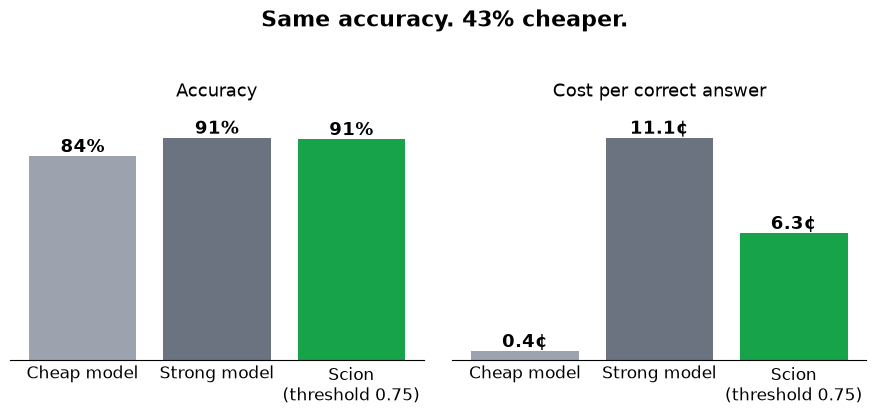

In [23]:
HEAD_T = 0.75
HEAD = [("Cheap model", "only-easy", "#9ca3af"), ("Strong model", "only-hard", "#6b7280"),
        (f"Scion\n(threshold {HEAD_T:g})", "scion-routed", "#16a34a")]
stats = {key: summarize(scion_routed(HEAD_T) if key == "scion-routed" else by_policy[key]) for _, key, _ in HEAD}
saving = 1 - stats["scion-routed"]["per_success"] / stats["only-hard"]["per_success"]
names, cols = [n for n, _, _ in HEAD], [c for _, _, c in HEAD]
acc = [stats[k]["acc"] * 100 for _, k, _ in HEAD]
cost = [stats[k]["per_success"] * 100 for _, k, _ in HEAD]      # cents per correct answer

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, vals, fmt, title in ((a1, acc, "{:.0f}%", "Accuracy"), (a2, cost, "{:.1f}¢", "Cost per correct answer")):
    ax.bar(names, vals, color=cols)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.02, fmt.format(v), ha="center", fontsize=13, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.15)
    ax.set_title(title, fontsize=13)
    ax.set_yticks([]); ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=12, length=0)
fig.suptitle(f"Same accuracy. {saving:.0%} cheaper.", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.savefig("fig_headline_routing.png", dpi=200, bbox_inches="tight"); plt.show()

In [24]:
# Stop paying for Scion's deployment.
fw.deployments.update(DEPLOYMENT_ID, base_model=BASE_MODEL, min_replica_count=0, max_replica_count=1)
fw.deployments.scale(DEPLOYMENT_ID, replica_count=0)
print("scaled to 0:", DEPLOYMENT_ID)

scaled to 0: jev-di-9b-0928
